In [1]:
from google.colab import files
uploaded = files.upload()

Saving Purchases.csv to Purchases.csv


In [3]:
import pandas as pd

df = pd.read_csv('/content/Purchases.csv')
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
snapshot_date = df['purchase_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('user_pseudo_id').agg(
    recency=('purchase_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('purchase_date', 'count'),
    monetary=('revenue', 'sum')
).reset_index()

rfm.head()

,user_pseudo_id,recency,frequency,monetary
0,1.014825e+06,90,1,183.0
1,1.016447e+06,42,1,86.0
2,1.019528e+06,58,1,44.0
3,1.021887e+06,37,1,21.0
4,1.026932e+06,55,4,213.0


In [4]:
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

In [5]:
def segment(row):
    if row['r_score'] in [4,3] and row['f_score'] in [3,4]:
        return 'Champions' if row['m_score'] in [3,4] else 'Loyal Customers'
    elif row['r_score'] in [4,3]:
        return 'New Customers'
    elif row['f_score'] in [3,4]:
        return 'At Risk'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(segment, axis=1)
rfm['segment'].value_counts()

,count
segment,
New Customers,1161
At Risk,1084
Needs Attention,1049
Champions,589
Loyal Customers,536


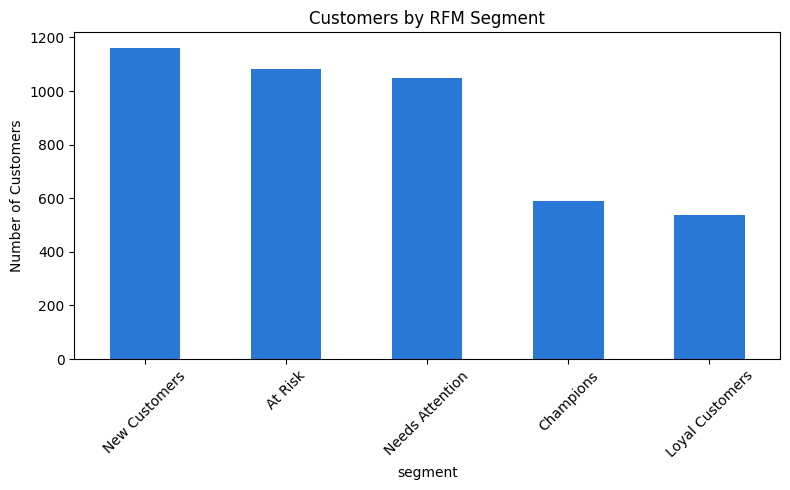

In [6]:
import matplotlib.pyplot as plt

rfm['segment'].value_counts().plot(kind='bar', color='#2a78d6', figsize=(8,5))
plt.title('Customers by RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rfm_segments.png')
plt.show()

In [7]:
rfm.groupby('segment')['monetary'].mean().round(2)

,monetary
segment,
At Risk,107.52
Champions,156.27
Loyal Customers,22.39
Needs Attention,68.72
New Customers,59.85
